In [2]:
import yaml
import matplotlib.pyplot as plt

# Dane wejściowe

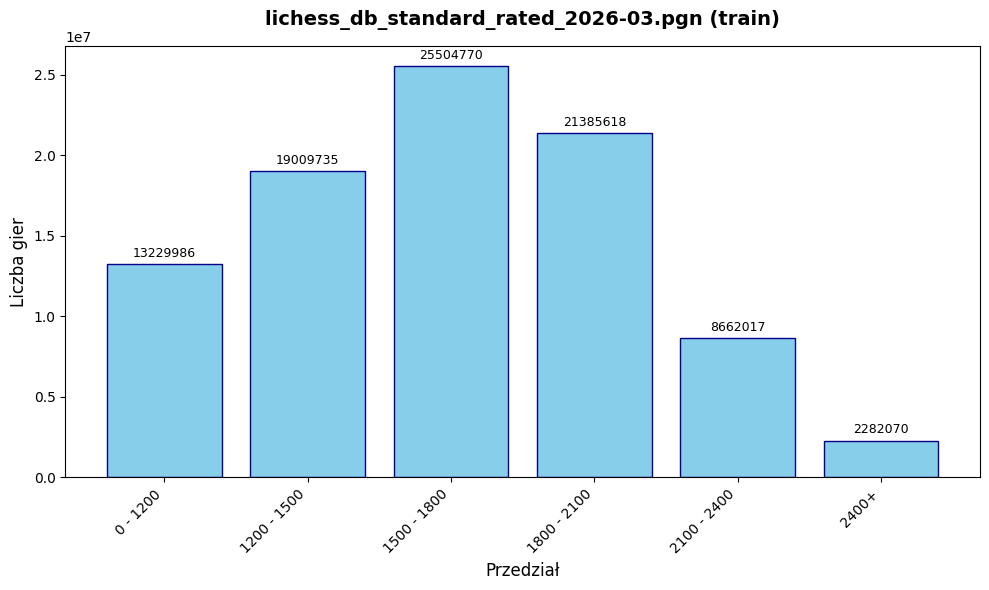

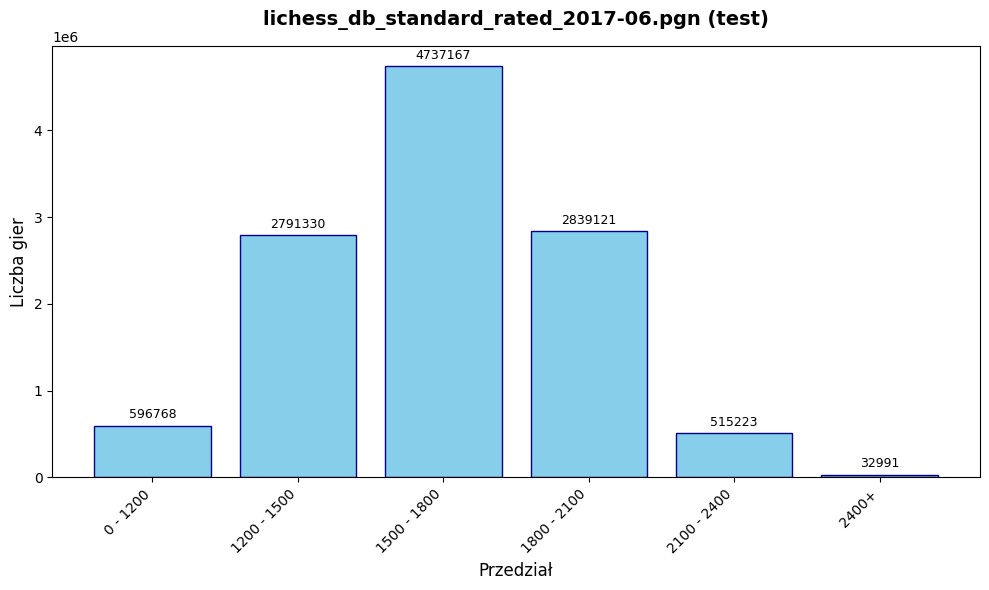

In [ ]:


# Define the path to your YAML file
yaml_file_paths = ['/home/adamz/Documents/praca-magisterska/data/input/split/train/data.yml',
                  '/home/adamz/Documents/praca-magisterska/data/input/split/test/data.yml']

for yaml_file_path in yaml_file_paths:

	# Open and parse the YAML file
	with open(yaml_file_path, 'r') as file:
		data = yaml.safe_load(file)

	# Extract the title and the breakdown data
	chart_title = data.get('file', 'Game Distribution')
	bucket_data = data.get('Breakdown by bucket', {})

	# In Python 3.7+, dictionary insertion order is preserved by default,
	# so converting directly to lists keeps the original file order.
	buckets = list(bucket_data.keys())
	counts = list(bucket_data.values())

	# Use subplots to set up dimensions safely
	fig, ax = plt.subplots(figsize=(10, 6))

	# Generate vertical bars using ax.bar
	bars = ax.bar(buckets, counts, color='skyblue', edgecolor='darkblue')

	# Add values above each vertical bar for clarity
	ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)

	# Set titles and axis labels
	ax.set_title(chart_title, fontsize=14, fontweight='bold', pad=15)
	ax.set_ylabel("Liczba gier", fontsize=12)
	ax.set_xlabel("Przedział", fontsize=12)

	# Rotate x-axis labels by 45 degrees and align them to prevent overlapping
	plt.xticks(rotation=45, ha='right')

	# Automatically adjust the padding so the rotated labels are completely visible
	plt.tight_layout()


	# Save the updated plot
	plt.savefig(f'bucket_distribution {chart_title}.png', dpi=300)

# błąd uczenia

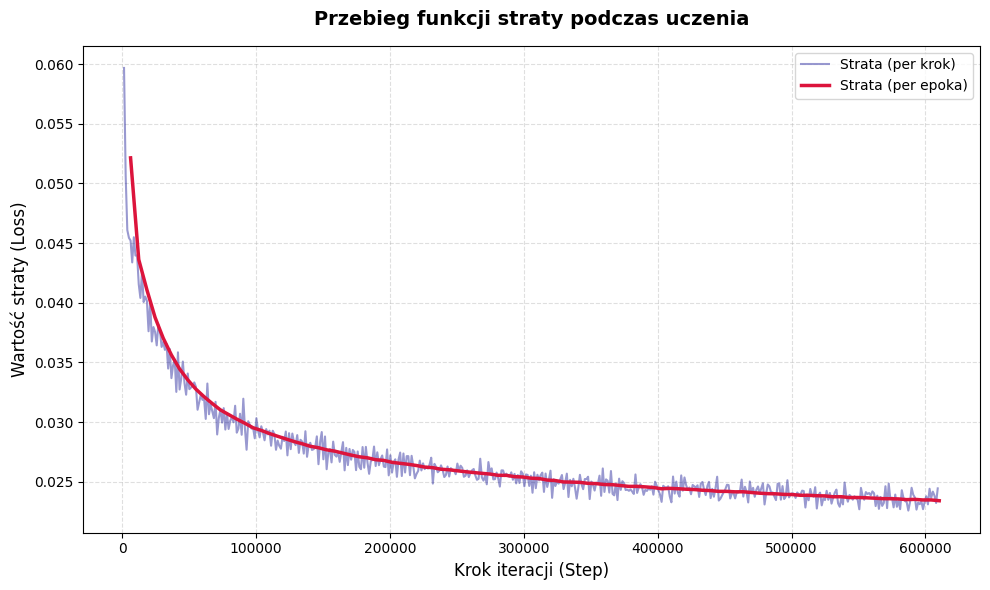

In [10]:
import io
import matplotlib.pyplot as plt
import pandas as pd

# Twoje dane CSV jako ciąg znaków (w realnym scenariuszu zamień na ścieżkę do pliku)
csv_data = "/home/adamz/Documents/praca-magisterska/data/trained_nets/1200_under/metrics.csv"

# Wczytanie danych (jeśli czytasz z pliku, użyj: pd.read_csv('sciezka_do_pliku.csv'))
df = pd.read_csv(csv_data)

# Przygotowanie czystych serii danych (odrzucenie NaN)
df_step = df.dropna(subset=["train_loss"])
df_epoch = df.dropna(subset=["train_loss_epoch"])

# Setup wykresu
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Linia kroków: dodany parametr alpha=0.4 dla przezroczystości
ax.plot(
    df_step["step"],
    df_step["train_loss"],
    color="darkblue",
    # marker="o",
    linewidth=1.5,
    markersize=4,
    alpha=0.4,
    label="Strata (per krok)",
)

# 2. Linia epok: zmienione z scatter na plot, by linia była ciągła
ax.plot(
    df_epoch["step"],
    df_epoch["train_loss_epoch"],
    color="crimson",
    # marker="X",
    linewidth=2.5,
    markersize=8,
    label="Strata (per epoka)",
)

# Stylistyka i opisy
ax.set_title(
    "Przebieg funkcji straty podczas uczenia",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Wartość straty (Loss)", fontsize=12)
ax.set_xlabel("Krok iteracji (Step)", fontsize=12)

# Dodatki graficzne
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("training_loss_continuous.png", dpi=300)